In [1]:
# Employee Promotion Prediction Analysis - NO IMBLEARN VERSION
"""Final Delivery Topic: Problem Description"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report, 
                           roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Data Loading and Basic Exploration
df = pd.read_csv('data/employee_promotion_updated.csv')

# Display key information
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['is_promoted'].value_counts(normalize=True))

# Show sample data
display(df.head(3))

Dataset Shape: (55808, 13)

Class Distribution:
is_promoted
0    0.907146
1    0.092854
Name: proportion, dtype: float64


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,Bangalore,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,Hyderabad,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,Pune,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0


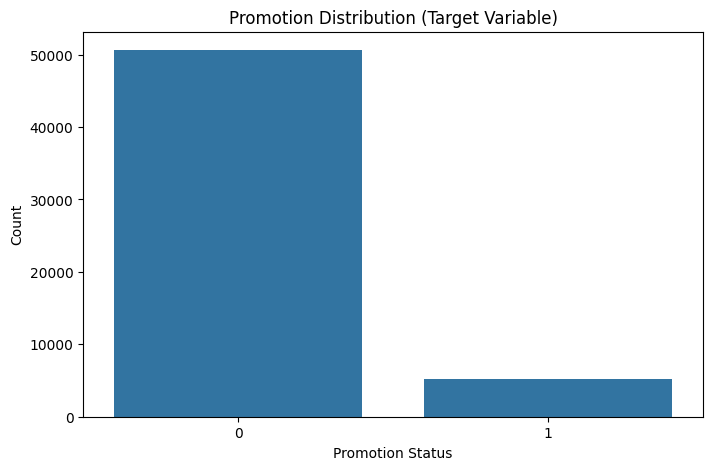

Promoted: 5182 (9.29%)
Not Promoted: 50626 (90.71%)


In [3]:
# Target Variable Analysis
"""
Final Delivery Topic: Problem Description
Visualizing the class distribution of our target variable.
"""
plt.figure(figsize=(8,5))
sns.countplot(x='is_promoted', data=df)
plt.title('Promotion Distribution (Target Variable)')
plt.xlabel('Promotion Status')
plt.ylabel('Count')
plt.show()

promoted = df['is_promoted'].value_counts()
print(f"Promoted: {promoted[1]} ({promoted[1]/len(df)*100:.2f}%)")
print(f"Not Promoted: {promoted[0]} ({promoted[0]/len(df)*100:.2f}%)")


=== Numerical Features ===

Checking for non-numeric values in numerical columns:
Column 'previous_year_rating' contains 4124 non-numeric values
Column 'avg_training_score' contains 2560 non-numeric values


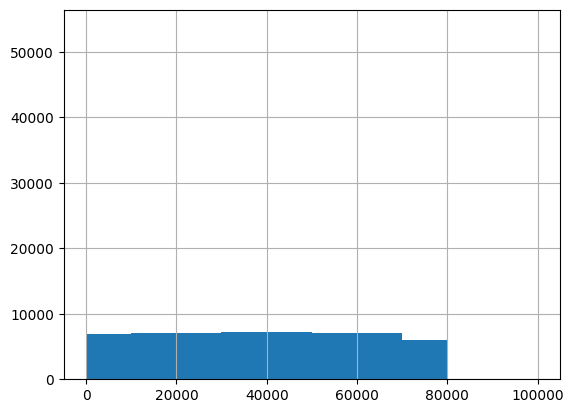

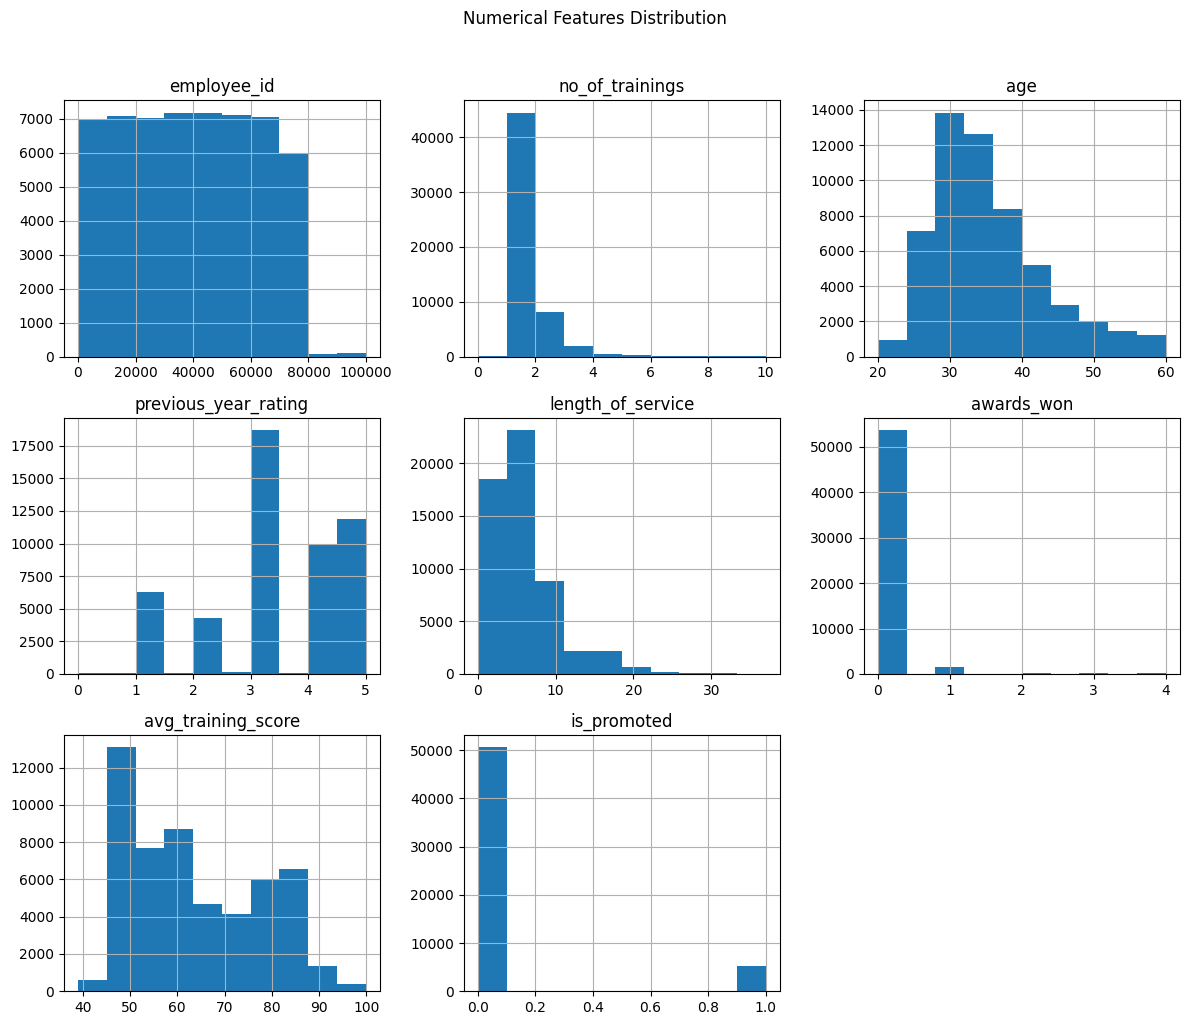


=== Categorical Features ===


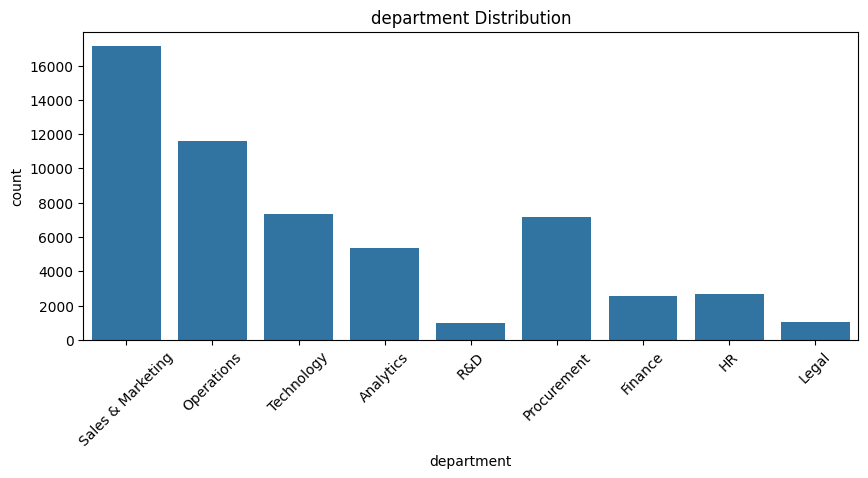


Value counts for department:
department
Sales & Marketing    17113
Operations           11593
Technology            7369
Procurement           7138
Analytics             5352
HR                    2669
Finance               2536
Legal                 1039
R&D                    999
Name: count, dtype: int64


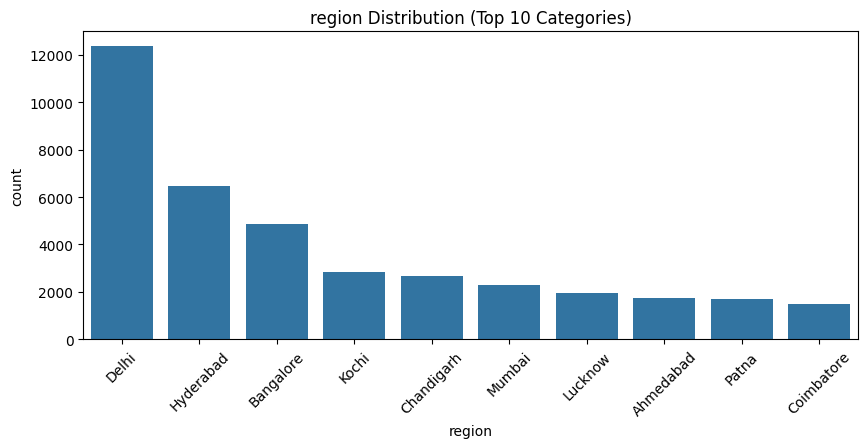


Value counts for region:
region
Delhi                 12369
Hyderabad              6451
Bangalore              4873
Kochi                  2834
Chandigarh             2671
Mumbai                 2294
Lucknow                1959
Ahmedabad              1735
Patna                  1694
Coimbatore             1497
Nagpur                 1352
Indore                 1335
Chennai                1202
Jaipur                 1025
Jamshedpur              977
Pune                    910
Noida                   879
Thiruvananthapuram      857
Mysore                  845
Visakhapatnam           823
Bhubaneswar             801
Dehradun                715
Ranchi                  696
Vadodara                677
Hubli                   677
Kolkata                 638
Amritsar                537
Guwahati                533
Shillong                444
Surat                   439
Pondicherry             377
Gurgaon                 317
Raipur                  303
Shimla                   72
Name: count, dt

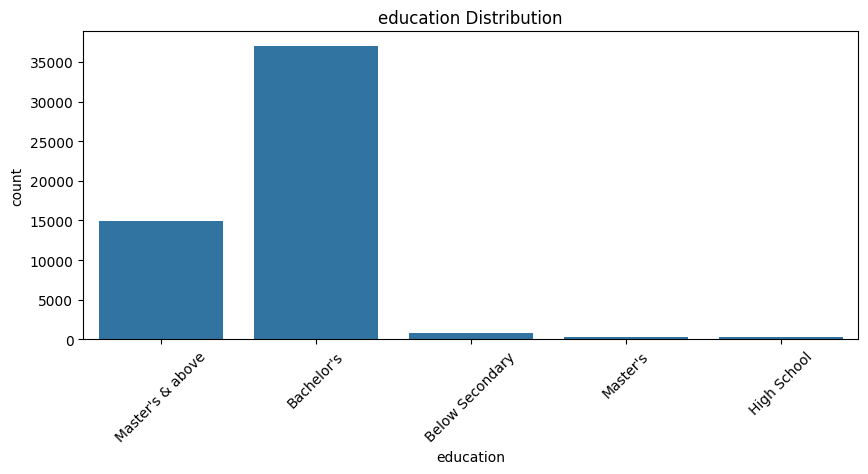


Value counts for education:
education
Bachelor's          36992
Master's & above    14925
Below Secondary       805
High School           357
Master's              320
Name: count, dtype: int64


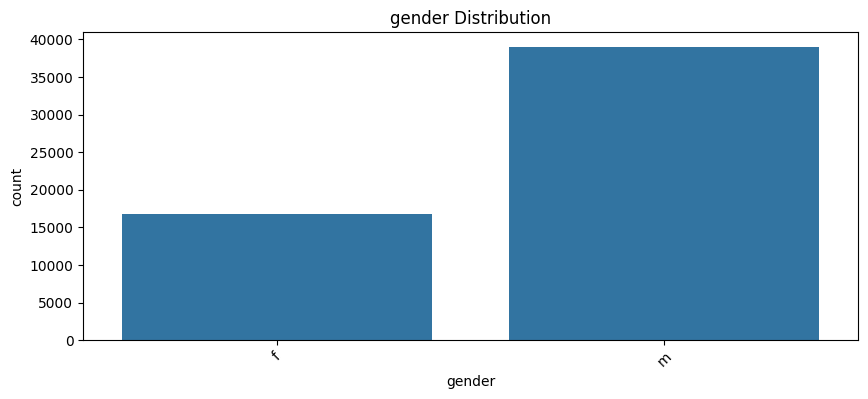


Value counts for gender:
gender
m    38991
f    16817
Name: count, dtype: int64


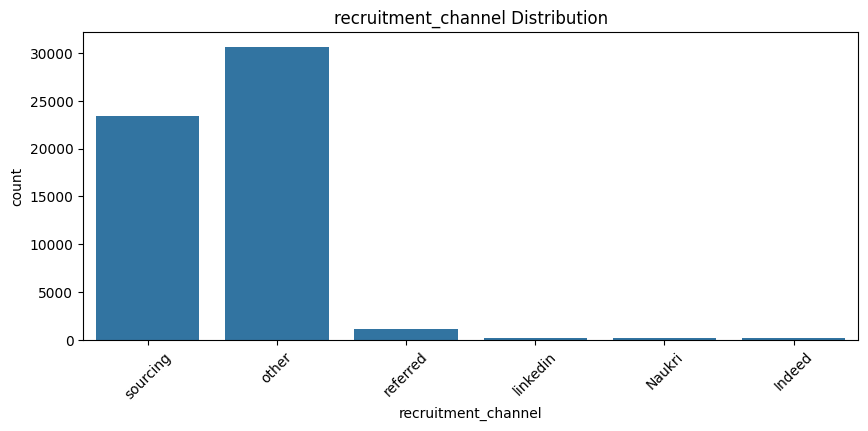


Value counts for recruitment_channel:
recruitment_channel
other       30653
sourcing    23421
referred     1142
Naukri        202
Indeed        199
linkedin      191
Name: count, dtype: int64

=== Feature Correlations ===


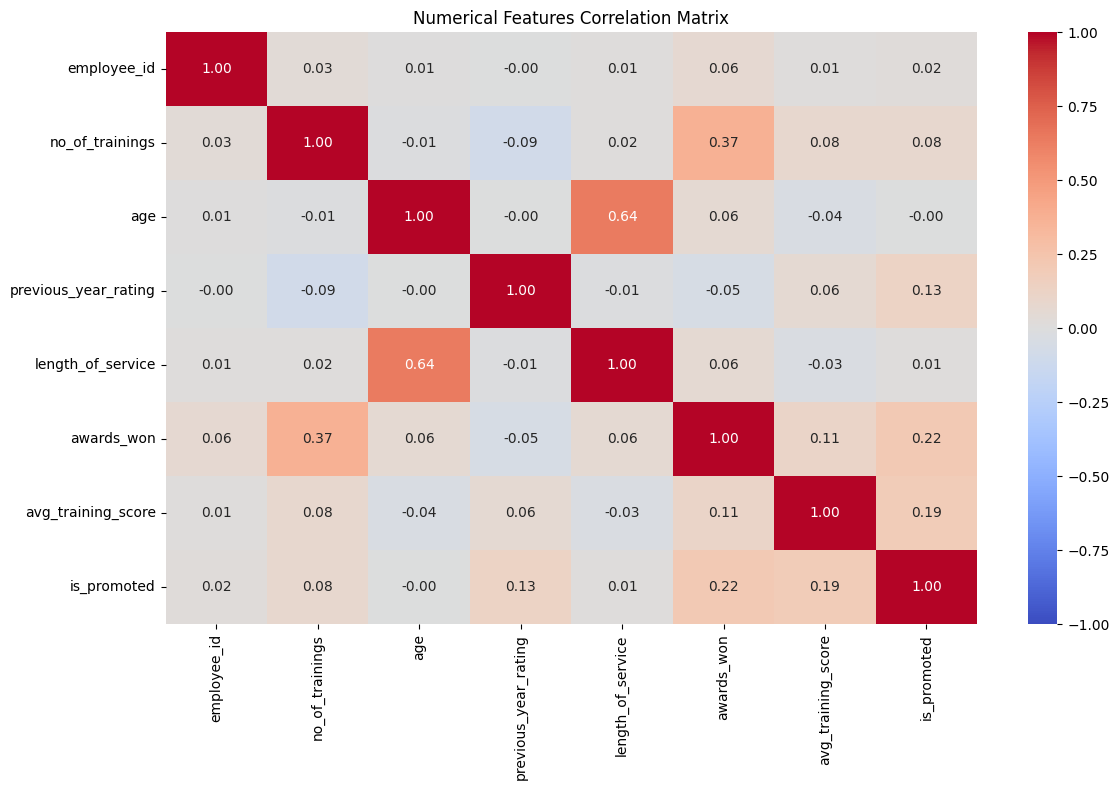


=== Relationships with Target Variable ===


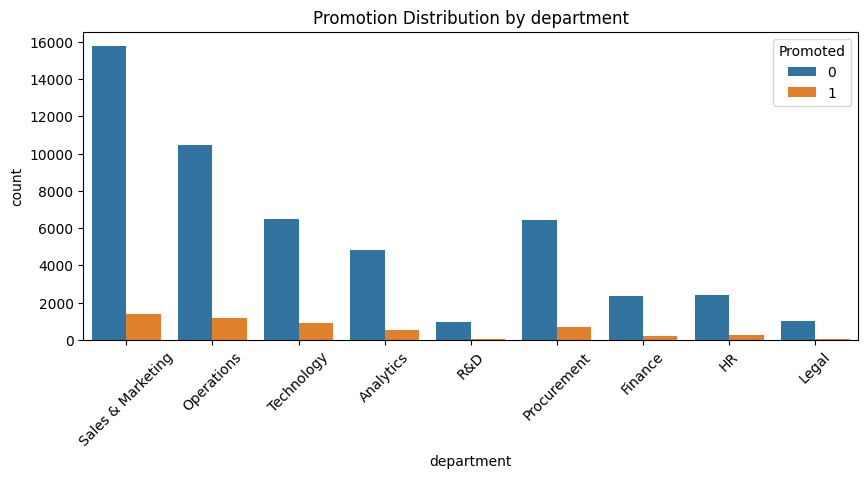

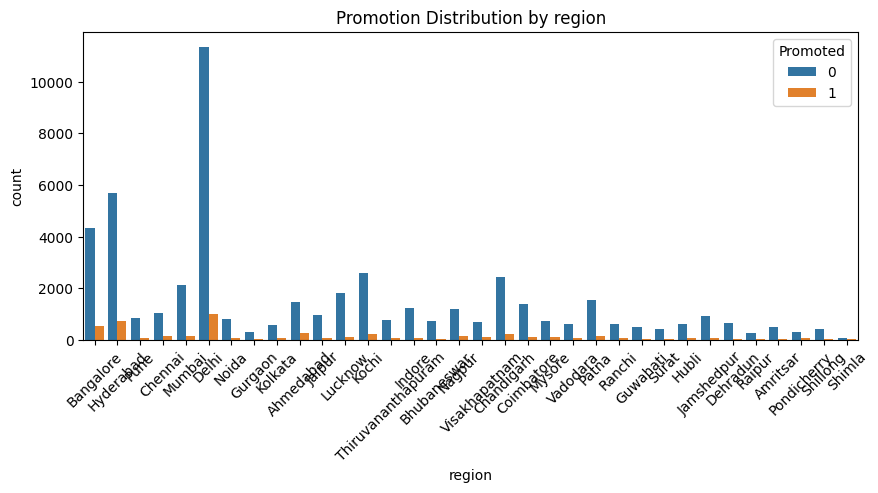

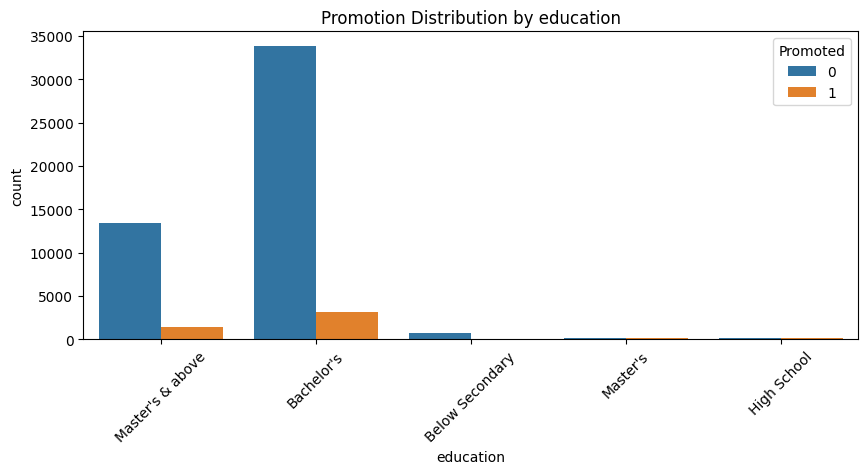

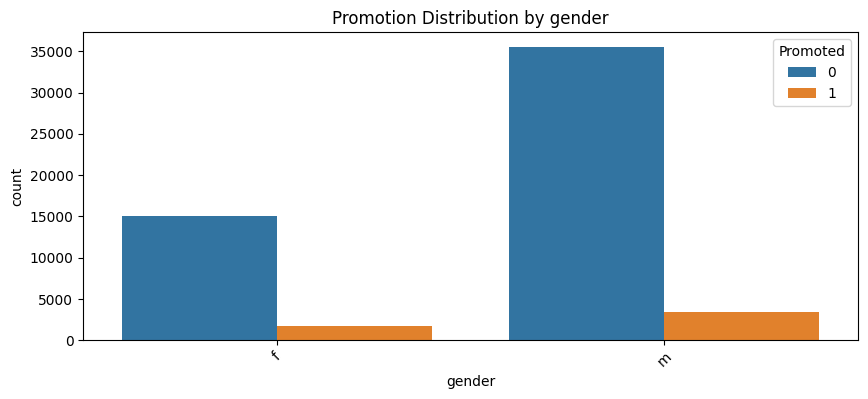

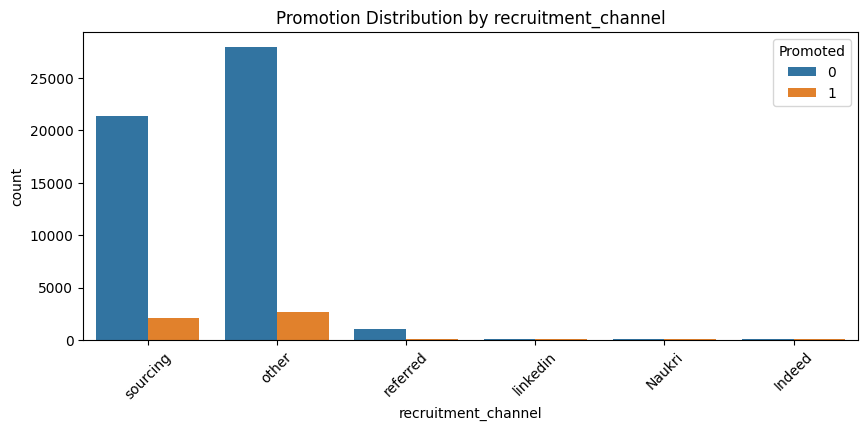

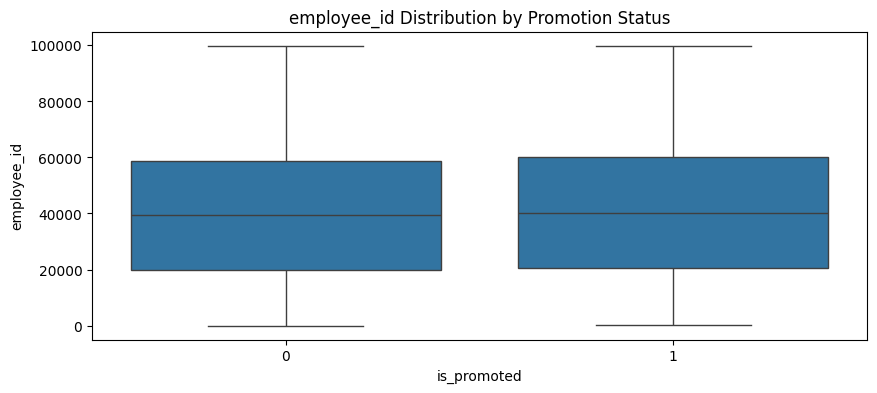

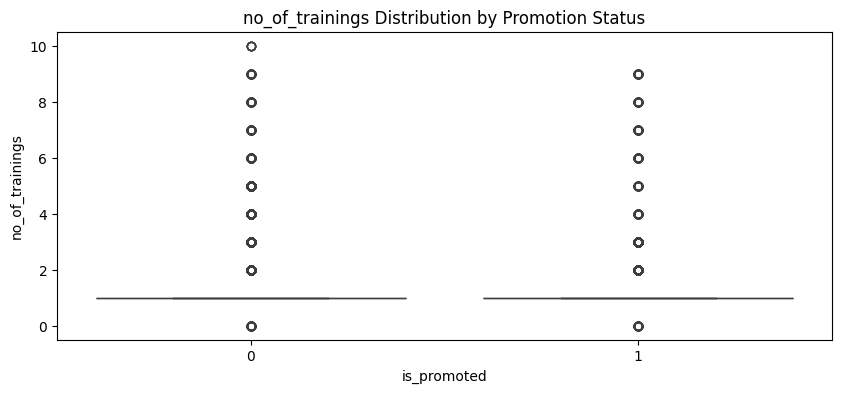

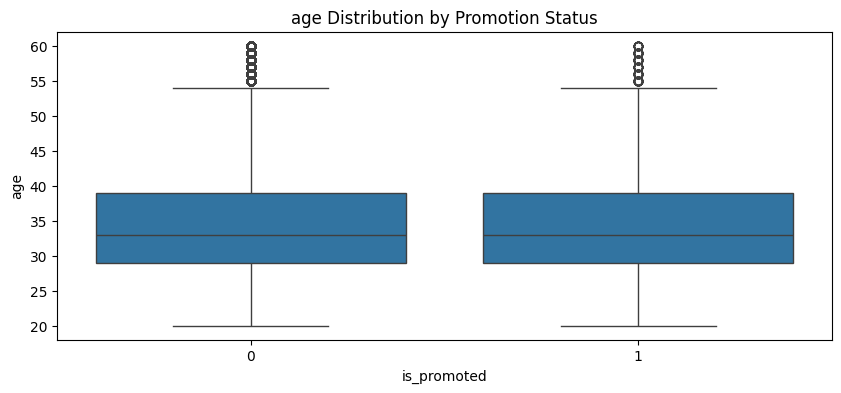

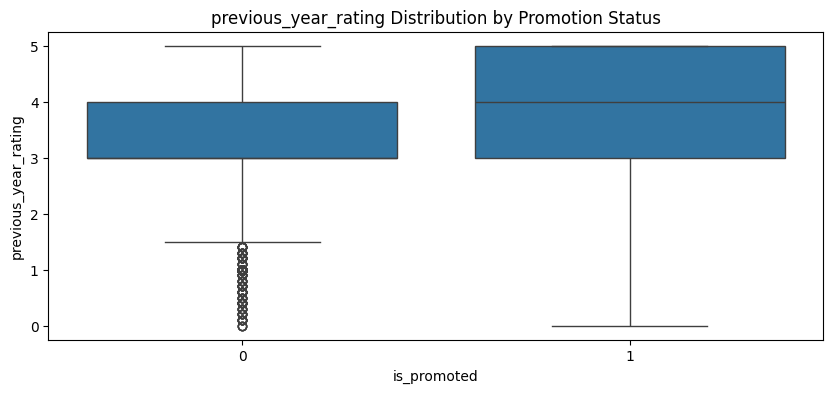

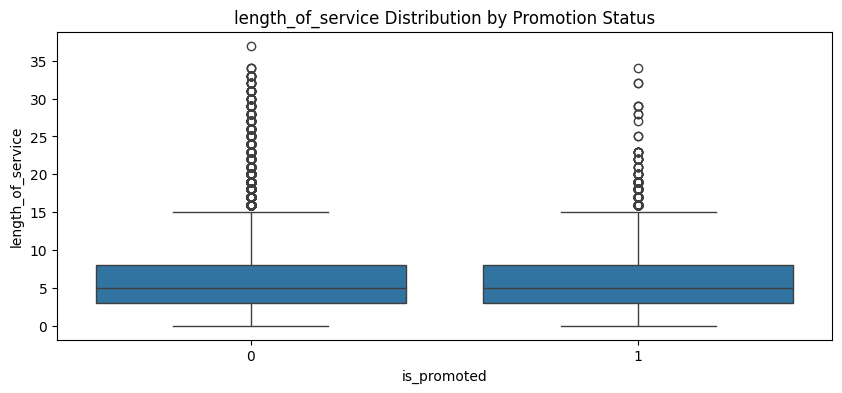

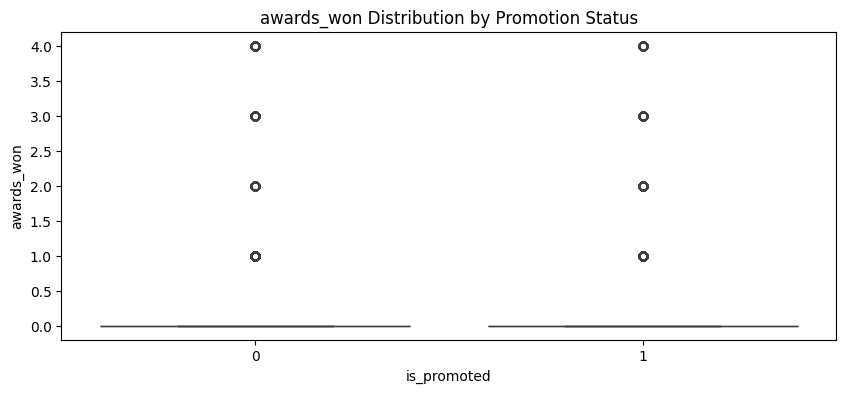

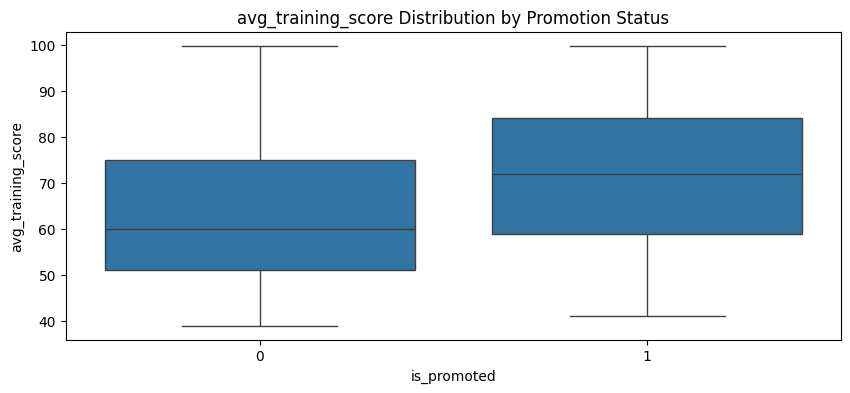

In [4]:
# Enhanced Feature Analysis
"""
Final Delivery Topic: Data Preprocessing
Comprehensive examination of feature distributions and relationships,
with proper handling of mixed data types.
"""

# 1. Numerical Features Analysis
from sklearn.calibration import LabelEncoder


print("\n=== Numerical Features ===")
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Check for non-numeric values in numerical columns
print("\nChecking for non-numeric values in numerical columns:")
for col in num_cols:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    if non_numeric > 0:
        print(f"Column '{col}' contains {non_numeric} non-numeric values")

# Plot distributions (only for truly numerical columns)
clean_num_cols = []
for col in num_cols:
    try:
        df[col].hist()
        clean_num_cols.append(col)
    except TypeError:
        print(f"Skipping column '{col}' - contains non-numeric values")

df[clean_num_cols].hist(figsize=(12,10))
plt.suptitle('Numerical Features Distribution', y=1.02)
plt.tight_layout()
plt.show()

# 2. Categorical Features Analysis
print("\n=== Categorical Features ===")
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10,4))
    
    # Handle cases with many categories
    if df[col].nunique() > 10:
        # Plot top 10 categories
        top_cats = df[col].value_counts().nlargest(10).index
        filtered_data = df[df[col].isin(top_cats)]
        sns.countplot(x=col, data=filtered_data, order=top_cats)
        plt.title(f'{col} Distribution (Top 10 Categories)')
    else:
        sns.countplot(x=col, data=df)
        plt.title(f'{col} Distribution')
    
    plt.xticks(rotation=45)
    plt.show()

    # Print value counts
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

# 3. Correlation Analysis
print("\n=== Feature Correlations ===")

# Create a copy for encoded correlation analysis
df_encoded = df.copy()

# Label encode categorical features properly
for col in cat_cols:
    if col in df_encoded.columns:  # Check if column still exists
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Calculate correlations (using only truly numerical columns)
corr_matrix = df_encoded[clean_num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            center=0, vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.tight_layout()
plt.show()

# 4. Target Variable Relationships
print("\n=== Relationships with Target Variable ===")

# For categorical features
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue='is_promoted', data=df)
    plt.title(f'Promotion Distribution by {col}')
    plt.xticks(rotation=45)
    plt.legend(title='Promoted', loc='upper right')
    plt.show()

# For numerical features
for col in clean_num_cols:
    if col != 'is_promoted':  # Skip target variable
        plt.figure(figsize=(10,4))
        sns.boxplot(x='is_promoted', y=col, data=df)
        plt.title(f'{col} Distribution by Promotion Status')
        plt.show()

In [5]:
# ULTRA-ROBUST DATA PREPROCESSING

# 1. Data Cleaning Before Preprocessing
# Handle infinite values and ensure proper types
from sklearn.impute import SimpleImputer
from sklearn.pipeline import FunctionTransformer, Pipeline


X = df.drop('is_promoted', axis=1).replace([np.inf, -np.inf], np.nan)
y = df['is_promoted']

# 2. Enhanced Column Identification
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns

# 3. Super Robust Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder='drop'
)

# 4. Data Validation Function
def validate_data(X):
    # X is 2D numpy array
    if np.isinf(X).any() or np.isnan(X).any():
        X = np.where(np.isinf(X), np.nan, X)
        # Replace NaNs column-wise with column median
        for i in range(X.shape[1]):
            col = X[:, i]
            if np.isnan(col).any():
                median = np.nanmedian(col)
                col[np.isnan(col)] = median
            X[:, i] = col
    return X

# 5. Apply Preprocessing with Validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Transform with validation
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Check for NaNs and Infs immediately after transformation, before validation
print("Before validation:")
print("Training - NaNs:", np.isnan(X_train_preprocessed).sum(), 
      "Infs:", np.isinf(X_train_preprocessed).sum())
print("Test - NaNs:", np.isnan(X_test_preprocessed).sum(), 
      "Infs:", np.isinf(X_test_preprocessed).sum())

# Now run validation
X_train_preprocessed = validate_data(X_train_preprocessed)
X_test_preprocessed = validate_data(X_test_preprocessed)

# Final validation check
print("After validation:")
print("Training - NaNs:", np.isnan(X_train_preprocessed).sum(), 
      "Infs:", np.isinf(X_train_preprocessed).sum())
print("Test - NaNs:", np.isnan(X_test_preprocessed).sum(), 
      "Infs:", np.isinf(X_test_preprocessed).sum())


Before validation:
Training - NaNs: 0 Infs: 0
Test - NaNs: 0 Infs: 0
After validation:
Training - NaNs: 0 Infs: 0
Test - NaNs: 0 Infs: 0


In [ ]:
# Model Training with Class Weighting
import time
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# Expanded hyperparameter grids for better model performance

from sklearn.model_selection import GridSearchCV

# Smaller, faster grids
dt_params = {
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'criterion': ['gini', 'entropy']
}

knn_params = {
    'n_neighbors': [5, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# Use cv=3 for faster search
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=3, scoring='f1', n_jobs=-1
)
dt_grid.fit(X_train_preprocessed, y_train)
print("Best Decision Tree params:", dt_grid.best_params_)

knn_grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_params, cv=3, scoring='f1', n_jobs=-1
)
knn_grid.fit(X_train_preprocessed, y_train)
print("Best KNN params:", knn_grid.best_params_)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=3, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train_preprocessed, y_train)
print("Best Random Forest params:", rf_grid.best_params_)

# Use the best estimators for further evaluation
best_dt = dt_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

models = {
    "Best Decision Tree": best_dt,
    "Best KNN": best_knn,
    "Best Random Forest": best_rf
}


# Train models
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_preprocessed, y_train)
    elapsed = time.time() - start_time
    print(f"{name} trained in {elapsed:.2f} seconds")
    
    # Check prediction distribution
    train_preds = model.predict(X_train_preprocessed)
    print(f"{name} training predictions:", np.bincount(train_preds))

Best Decision Tree params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best KNN params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Best Random Forest params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Decision Tree trained in 0.95 seconds
Best Decision Tree training predictions: [42387  2259]
Best KNN trained in 0.01 seconds
Best KNN training predictions: [40500  4146]
Best Random Forest trained in 8.00 seconds
Best Random Forest training predictions: [40093  4553]


In [23]:
# Model Training with Class Weighting and More Imbalance-Suited Models
import time
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# Expanded hyperparameter grids for better model performance

# Smaller, faster grids
best_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=42
)

best_knn = KNeighborsClassifier(
    n_neighbors=5,
    p=2,
    weights='distance',
    n_jobs=-1
)

best_rf = RandomForestClassifier(
    class_weight='balanced',
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging = BaggingClassifier(
    estimator=best_dt,
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

extra_trees = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

models = {
    "Best Decision Tree": best_dt,
    "Best KNN": best_knn,
    "Best Random Forest": best_rf,
    "Bagging (Decision Tree)": bagging,
    "Extra Trees": extra_trees,
    "Logistic Regression": logreg,
    "Gradient Boosting": gbc
}

# Train models
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_preprocessed, y_train)
    elapsed = time.time() - start_time
    print(f"{name} trained in {elapsed:.2f} seconds")
    
    # Check prediction distribution
    train_preds = model.predict(X_train_preprocessed)
    print(f"{name} training predictions:", np.bincount(train_preds))

Best Decision Tree trained in 0.70 seconds
Best Decision Tree training predictions: [42387  2259]
Best KNN trained in 0.01 seconds
Best KNN training predictions: [40500  4146]
Best Random Forest trained in 4.05 seconds
Best Random Forest training predictions: [40093  4553]
Bagging (Decision Tree) trained in 12.91 seconds
Bagging (Decision Tree) training predictions: [42741  1905]
Extra Trees trained in 4.14 seconds
Extra Trees training predictions: [38270  6376]
Logistic Regression trained in 1.28 seconds
Logistic Regression training predictions: [32990 11656]
Gradient Boosting trained in 24.73 seconds
Gradient Boosting training predictions: [43348  1298]


In [24]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, classification_report

# Calibrate models that support predict_proba
calibrated_models = {}
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        calibrated = CalibratedClassifierCV(model, method='isotonic', cv=3)
        calibrated.fit(X_train_preprocessed, y_train)
        calibrated_models[name] = calibrated
    else:
        calibrated_models[name] = model  # fallback for models without predict_proba

print("Model parameters being used for threshold tuning (after calibration):")
for name, model in calibrated_models.items():
    print(f"{name}: {model.get_params() if hasattr(model, 'get_params') else 'N/A'}")

best_thresholds = {}

for name, model in calibrated_models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_preprocessed)[:, 1]
        prec, rec, thresh = precision_recall_curve(y_test, probs)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
        best_idx = f1.argmax()
        best_thresh = thresh[best_idx]
        best_thresholds[name] = best_thresh
        print(f"\n[{name}]")
        print(f"  Best F1: {f1[best_idx]:.3f} at threshold: {best_thresh:.2f}")
        y_pred_opt = (probs > best_thresh).astype(int)
        print(f"  Classification Report (Optimized Threshold):")
        print(classification_report(y_test, y_pred_opt, digits=3))
    else:
        print(f"\n[{name}] does not support predict_proba, skipping threshold tuning.")

print("\nBest thresholds for each model:", best_thresholds)

Model parameters being used for threshold tuning (after calibration):
Best Decision Tree: {'cv': 3, 'ensemble': 'auto', 'estimator__ccp_alpha': 0.0, 'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': 20, 'estimator__max_features': None, 'estimator__max_leaf_nodes': None, 'estimator__min_impurity_decrease': 0.0, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 10, 'estimator__min_weight_fraction_leaf': 0.0, 'estimator__monotonic_cst': None, 'estimator__random_state': 42, 'estimator__splitter': 'best', 'estimator': DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42), 'method': 'isotonic', 'n_jobs': None}
Best KNN: {'cv': 3, 'ensemble': 'auto', 'estimator__algorithm': 'auto', 'estimator__leaf_size': 30, 'estimator__metric': 'minkowski', 'estimator__metric_params': None, 'estimator__n_jobs': -1, 'estimator__n_neighbors': 5, 'estimator__p': 2, 'estimator__weights': 'distance', 'estimator': KNeighborsClassifier(n_

MODEL: BEST DECISION TREE

--- Default Threshold (0.5) ---
Accuracy:  0.922
Precision: 0.633
Recall:    0.374
F1:        0.470
ROC AUC:   0.725
Avg Precision: 0.404

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.938     0.978     0.958     10126
           1      0.633     0.374     0.470      1036

    accuracy                          0.922     11162
   macro avg      0.786     0.676     0.714     11162
weighted avg      0.910     0.922     0.913     11162



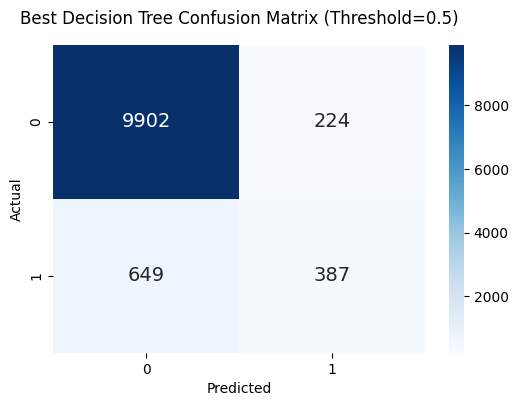

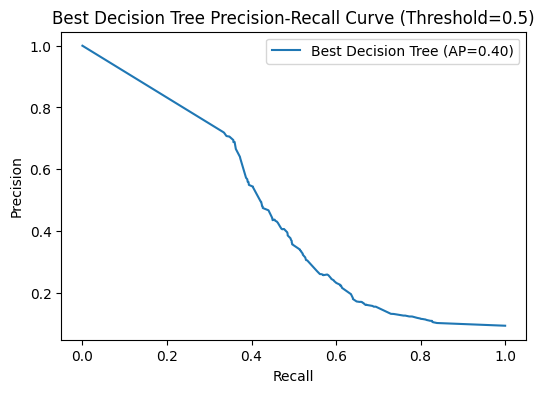


--- Optimized Threshold (0.70) ---
Accuracy:  0.925
Precision: 0.688
Recall:    0.357
F1:        0.473

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.937     0.983     0.960     10126
           1      0.688     0.357     0.470      1036

    accuracy                          0.925     11162
   macro avg      0.813     0.670     0.715     11162
weighted avg      0.914     0.925     0.914     11162



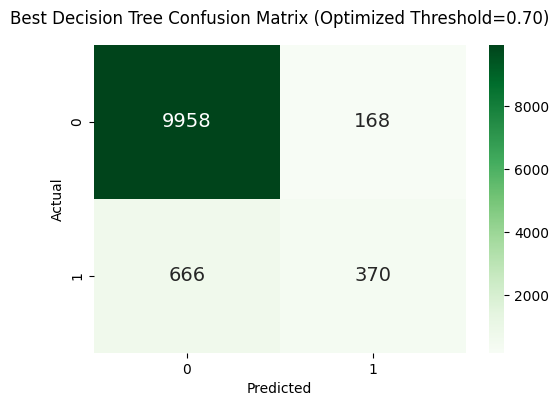




MODEL: BEST KNN

--- Default Threshold (0.5) ---
Accuracy:  0.910
Precision: 0.545
Recall:    0.168
F1:        0.257
ROC AUC:   0.692
Avg Precision: 0.285

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.921     0.986     0.952     10126
           1      0.545     0.168     0.257      1036

    accuracy                          0.910     11162
   macro avg      0.733     0.577     0.604     11162
weighted avg      0.886     0.910     0.887     11162



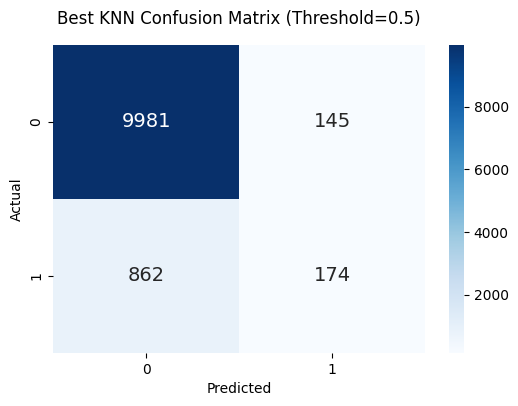

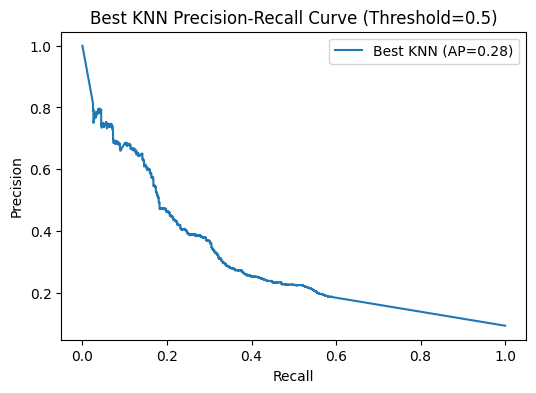


--- Optimized Threshold (0.36) ---
Accuracy:  0.887
Precision: 0.367
Recall:    0.300
F1:        0.331

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.930     0.947     0.938     10126
           1      0.367     0.300     0.330      1036

    accuracy                          0.887     11162
   macro avg      0.648     0.624     0.634     11162
weighted avg      0.878     0.887     0.882     11162



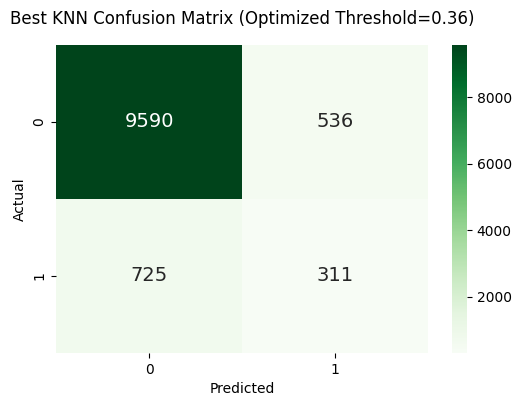




MODEL: BEST RANDOM FOREST

--- Default Threshold (0.5) ---
Accuracy:  0.919
Precision: 0.584
Recall:    0.458
F1:        0.513
ROC AUC:   0.824
Avg Precision: 0.527

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.946     0.967     0.956     10126
           1      0.584     0.458     0.513      1036

    accuracy                          0.919     11162
   macro avg      0.765     0.712     0.735     11162
weighted avg      0.912     0.919     0.915     11162



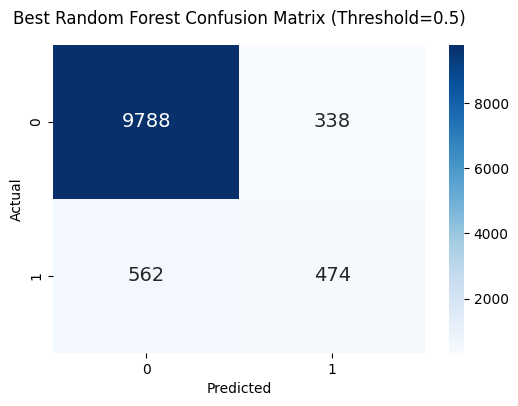

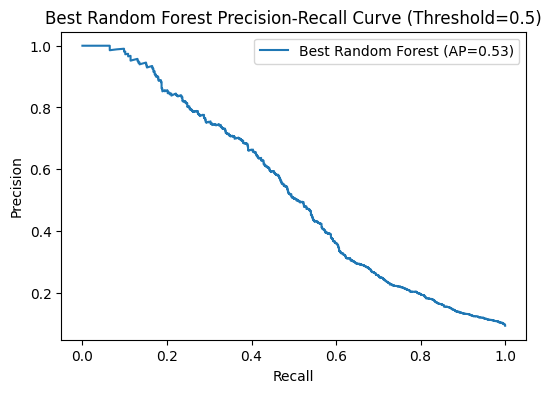


--- Optimized Threshold (0.50) ---
Accuracy:  0.919
Precision: 0.581
Recall:    0.462
F1:        0.516

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.946     0.966     0.956     10126
           1      0.581     0.462     0.515      1036

    accuracy                          0.919     11162
   macro avg      0.764     0.714     0.735     11162
weighted avg      0.912     0.919     0.915     11162



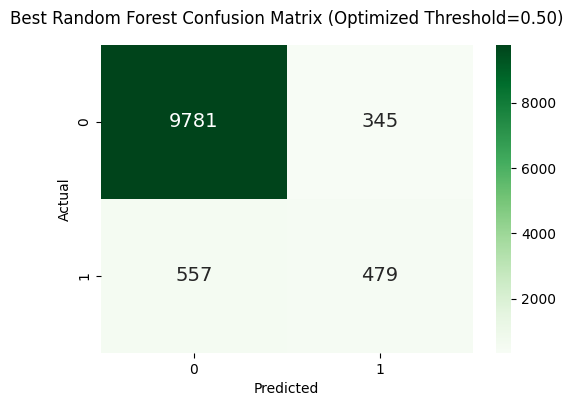




MODEL: BAGGING (DECISION TREE)

--- Default Threshold (0.5) ---
Accuracy:  0.931
Precision: 0.777
Recall:    0.357
F1:        0.489
ROC AUC:   0.821
Avg Precision: 0.563

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.938     0.990     0.963     10126
           1      0.777     0.357     0.489      1036

    accuracy                          0.931     11162
   macro avg      0.857     0.673     0.726     11162
weighted avg      0.923     0.931     0.919     11162



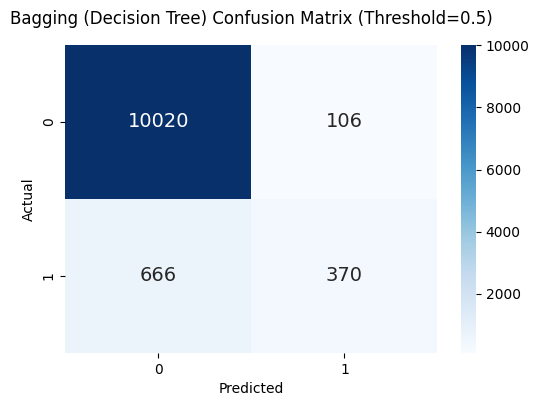

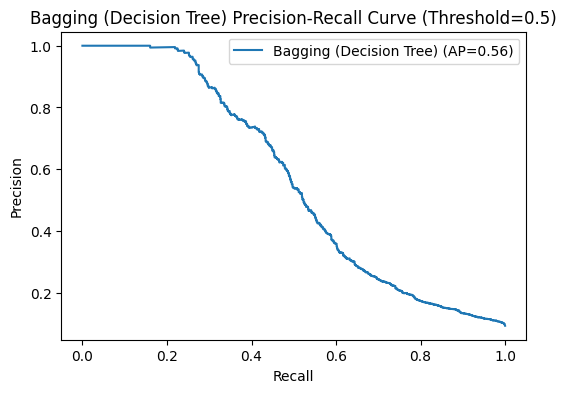


--- Optimized Threshold (0.29) ---
Accuracy:  0.924
Precision: 0.620
Recall:    0.474
F1:        0.538

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.947     0.970     0.959     10126
           1      0.620     0.474     0.537      1036

    accuracy                          0.924     11162
   macro avg      0.784     0.722     0.748     11162
weighted avg      0.917     0.924     0.920     11162



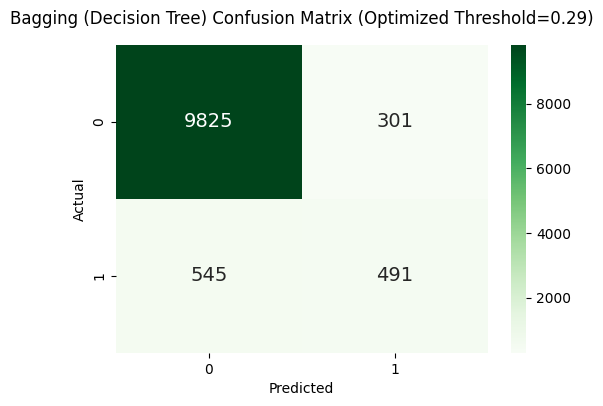




MODEL: EXTRA TREES

--- Default Threshold (0.5) ---
Accuracy:  0.881
Precision: 0.396
Recall:    0.526
F1:        0.452
ROC AUC:   0.819
Avg Precision: 0.477

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.950     0.918     0.934     10126
           1      0.396     0.526     0.452      1036

    accuracy                          0.881     11162
   macro avg      0.673     0.722     0.693     11162
weighted avg      0.898     0.881     0.889     11162



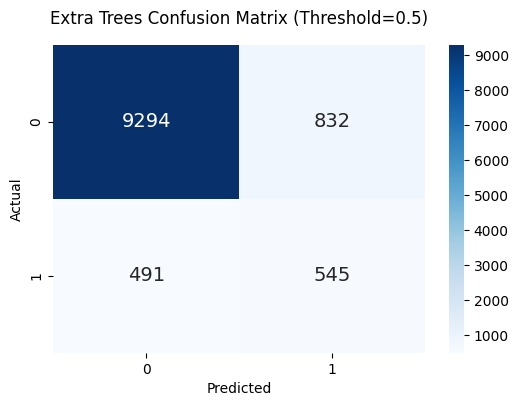

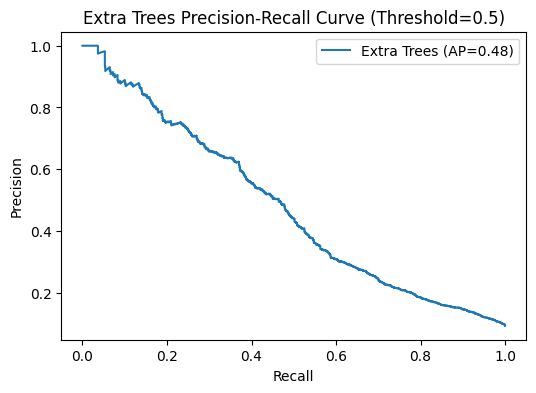


--- Optimized Threshold (0.57) ---
Accuracy:  0.908
Precision: 0.503
Recall:    0.463
F1:        0.483

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.946     0.953     0.949     10126
           1      0.503     0.463     0.482      1036

    accuracy                          0.908     11162
   macro avg      0.724     0.708     0.716     11162
weighted avg      0.904     0.908     0.906     11162



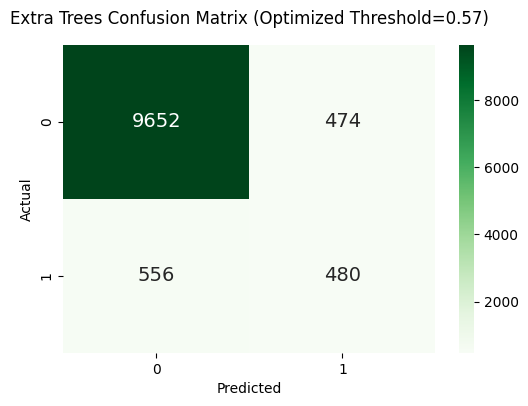




MODEL: LOGISTIC REGRESSION

--- Default Threshold (0.5) ---
Accuracy:  0.782
Precision: 0.253
Recall:    0.692
F1:        0.370
ROC AUC:   0.818
Avg Precision: 0.459

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.962     0.791     0.868     10126
           1      0.253     0.692     0.370      1036

    accuracy                          0.782     11162
   macro avg      0.607     0.741     0.619     11162
weighted avg      0.896     0.782     0.822     11162



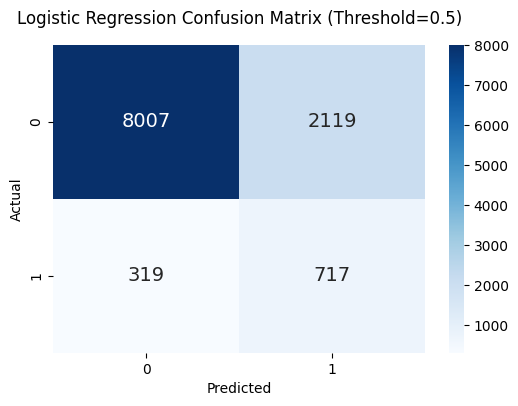

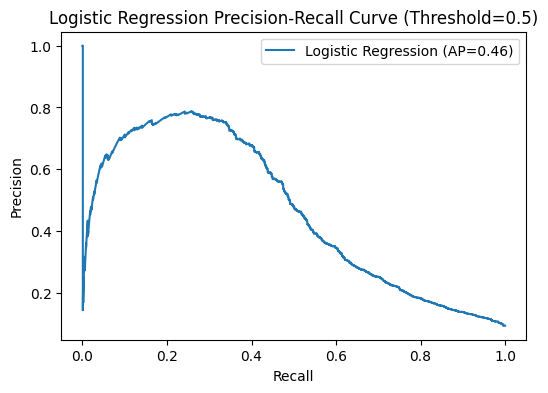


--- Optimized Threshold (0.70) ---
Accuracy:  0.917
Precision: 0.560
Recall:    0.470
F1:        0.512

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.947     0.962     0.954     10126
           1      0.560     0.470     0.511      1036

    accuracy                          0.917     11162
   macro avg      0.753     0.716     0.733     11162
weighted avg      0.911     0.917     0.913     11162



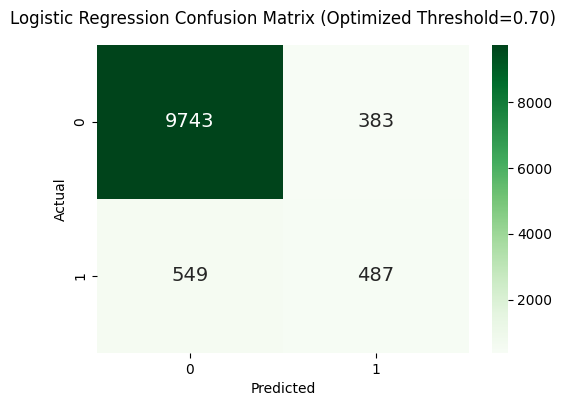




MODEL: GRADIENT BOOSTING

--- Default Threshold (0.5) ---
Accuracy:  0.927
Precision: 0.835
Recall:    0.264
F1:        0.401
ROC AUC:   0.832
Avg Precision: 0.551

Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0      0.930     0.995     0.961     10126
           1      0.835     0.264     0.401      1036

    accuracy                          0.927     11162
   macro avg      0.882     0.629     0.681     11162
weighted avg      0.921     0.927     0.909     11162



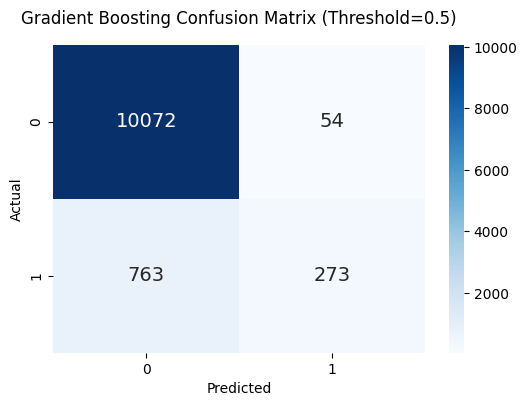

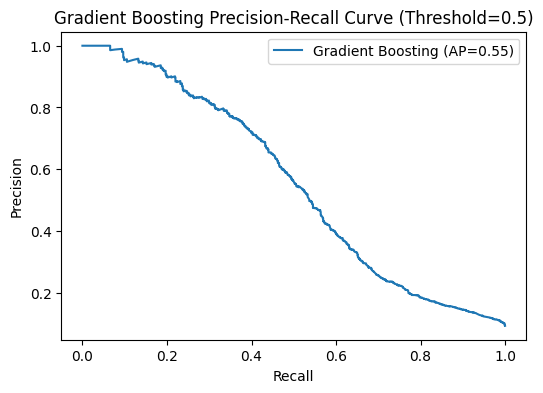


--- Optimized Threshold (0.23) ---
Accuracy:  0.926
Precision: 0.644
Recall:    0.454
F1:        0.533

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0      0.946     0.974     0.960     10126
           1      0.644     0.454     0.532      1036

    accuracy                          0.926     11162
   macro avg      0.795     0.714     0.746     11162
weighted avg      0.918     0.926     0.920     11162



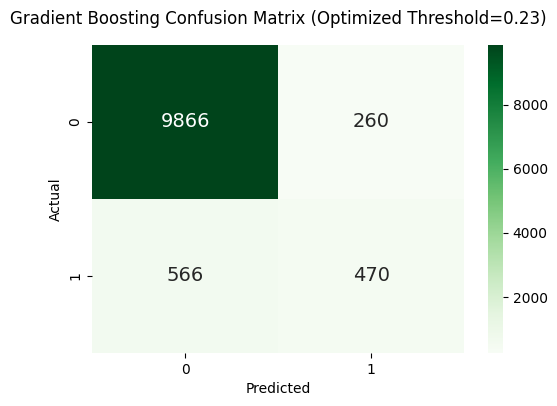





=== Metrics at Default Threshold (0.5) ===


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Avg Precision
2,Best Random Forest,0.919369,0.583744,0.457529,0.512987,0.823502,0.526943
3,Bagging (Decision Tree),0.930837,0.777311,0.357143,0.489418,0.821111,0.562801
0,Best Decision Tree,0.921788,0.633388,0.373552,0.469945,0.724877,0.404193
4,Extra Trees,0.881473,0.395788,0.526062,0.451720,0.819342,0.477315
6,Gradient Boosting,0.926805,0.834862,0.263514,0.400587,0.832438,0.551440
5,Logistic Regression,0.781580,0.252821,0.692085,0.370351,0.817658,0.458852
1,Best KNN,0.909783,0.545455,0.167954,0.256827,0.692427,0.284655



=== Best F1 and Thresholds (Threshold Tuning) ===


,Model,Best Threshold,Opt Accuracy,Opt Precision,Opt Recall,Opt F1
3,Bagging (Decision Tree),0.290585,0.924207,0.619949,0.473938,0.537999
6,Gradient Boosting,0.226182,0.925999,0.643836,0.453668,0.533107
2,Best Random Forest,0.495227,0.919190,0.581311,0.462355,0.515852
5,Logistic Regression,0.695905,0.916502,0.559770,0.470077,0.511799
4,Extra Trees,0.566384,0.907723,0.503145,0.463320,0.483174
0,Best Decision Tree,0.700000,0.925282,0.687732,0.357143,0.472750
1,Best KNN,0.360240,0.887027,0.367178,0.300193,0.331210



=== Improvement from Threshold Optimization ===


,Model,Accuracy,Opt Accuracy,Accuracy Δ,Precision,Opt Precision,Precision Δ,Recall,Opt Recall,Recall Δ,F1,Opt F1,F1 Δ,Best Threshold
0,Best Random Forest,0.919369,0.919190,-0.000179,0.583744,0.581311,-0.002433,0.457529,0.462355,0.004826,0.512987,0.515852,0.002865,0.495227
1,Bagging (Decision Tree),0.930837,0.924207,-0.006630,0.777311,0.619949,-0.157361,0.357143,0.473938,0.116795,0.489418,0.537999,0.048581,0.290585
2,Best Decision Tree,0.921788,0.925282,0.003494,0.633388,0.687732,0.054344,0.373552,0.357143,-0.016409,0.469945,0.472750,0.002805,0.700000
3,Extra Trees,0.881473,0.907723,0.026250,0.395788,0.503145,0.107357,0.526062,0.463320,-0.062741,0.451720,0.483174,0.031454,0.566384
4,Gradient Boosting,0.926805,0.925999,-0.000806,0.834862,0.643836,-0.191027,0.263514,0.453668,0.190154,0.400587,0.533107,0.132520,0.226182
5,Logistic Regression,0.781580,0.916502,0.134922,0.252821,0.559770,0.306949,0.692085,0.470077,-0.222008,0.370351,0.511799,0.141447,0.695905
6,Best KNN,0.909783,0.887027,-0.022756,0.545455,0.367178,-0.178276,0.167954,0.300193,0.132239,0.256827,0.331210,0.074384,0.360240


In [25]:
# Comprehensive Model Evaluation with Threshold Tuning (Improved Output)

from sklearn.metrics import precision_recall_curve, classification_report

results = []
threshold_results = []

for name, model in models.items():
    print("="*60)
    print(f"MODEL: {name.upper()}")
    print("="*60)
    
    # --- Default threshold (0.5) evaluation ---
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:,1] if hasattr(model, "predict_proba") else np.zeros(len(X_test))
    
    # Metrics at default threshold
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    
    results.append([name, accuracy, precision, recall, f1, roc_auc, avg_precision])
    
    print(f"\n--- Default Threshold (0.5) ---")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"ROC AUC:   {roc_auc:.3f}")
    print(f"Avg Precision: {avg_precision:.3f}")
    print("\nClassification Report (Threshold=0.5):")
    print(classification_report(y_test, y_pred, digits=3))
    
    # Confusion matrix at default threshold
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                annot_kws={"size": 14})
    plt.title(f'{name} Confusion Matrix (Threshold=0.5)', pad=15)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # PR Curve at default threshold
    plt.figure(figsize=(6,4))
    plt.plot(recall_curve, precision_curve, label=f'{name} (AP={avg_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} Precision-Recall Curve (Threshold=0.5)')
    plt.legend()
    plt.show()
    
    # --- Threshold tuning for models with predict_proba ---
    if hasattr(model, "predict_proba"):
        probs = y_prob
        prec, rec, thresh = precision_recall_curve(y_test, probs)
        f1s = 2 * (prec * rec) / (prec + rec + 1e-8)
        best_idx = f1s.argmax()
        best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5
        y_pred_opt = (probs > best_thresh).astype(int)
        opt_accuracy = accuracy_score(y_test, y_pred_opt)
        opt_precision = precision_score(y_test, y_pred_opt, zero_division=0)
        opt_recall = recall_score(y_test, y_pred_opt)
        opt_f1 = f1s[best_idx]
        threshold_results.append([name, best_thresh, opt_accuracy, opt_precision, opt_recall, opt_f1])
        
        print(f"\n--- Optimized Threshold ({best_thresh:.2f}) ---")
        print(f"Accuracy:  {opt_accuracy:.3f}")
        print(f"Precision: {opt_precision:.3f}")
        print(f"Recall:    {opt_recall:.3f}")
        print(f"F1:        {opt_f1:.3f}")
        print("\nClassification Report (Optimized Threshold):")
        print(classification_report(y_test, y_pred_opt, digits=3))
        
        # Confusion matrix at optimized threshold
        plt.figure(figsize=(6,4))
        sns.heatmap(confusion_matrix(y_test, y_pred_opt), 
                    annot=True, fmt='d', cmap='Greens',
                    annot_kws={"size": 14})
        plt.title(f'{name} Confusion Matrix (Optimized Threshold={best_thresh:.2f})', pad=15)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    else:
        print("\n(No threshold optimization: model does not support predict_proba)")
    print("\n\n")

# Results DataFrames
results_df = pd.DataFrame(results, 
                         columns=['Model', 'Accuracy', 'Precision', 
                                 'Recall', 'F1', 'ROC AUC', 'Avg Precision'])
results_df.sort_values('F1', ascending=False, inplace=True)

threshold_df = pd.DataFrame(threshold_results, columns=['Model', 'Best Threshold', 'Opt Accuracy', 'Opt Precision', 'Opt Recall', 'Opt F1'])
threshold_df.sort_values('Opt F1', ascending=False, inplace=True)

# Merge for improvement comparison
comparison_df = pd.merge(
    results_df, 
    threshold_df, 
    on='Model', 
    how='left', 
    suffixes=('_Default', '_Opt')
)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    comparison_df[f'{metric} Δ'] = comparison_df[f'Opt {metric}'] - comparison_df[f'{metric}']

print("\n=== Metrics at Default Threshold (0.5) ===")
display(results_df.style.background_gradient(cmap='Blues', subset=['F1', 'ROC AUC', 'Avg Precision']))

print("\n=== Best F1 and Thresholds (Threshold Tuning) ===")
display(threshold_df.style.background_gradient(cmap='Greens', subset=['Opt F1']))

print("\n=== Improvement from Threshold Optimization ===")
display(comparison_df[['Model', 'Accuracy', 'Opt Accuracy', 'Accuracy Δ', 
                       'Precision', 'Opt Precision', 'Precision Δ',
                       'Recall', 'Opt Recall', 'Recall Δ',
                       'F1', 'Opt F1', 'F1 Δ', 'Best Threshold']].style.background_gradient(cmap='RdYlGn', subset=['F1 Δ']))

<Figure size 1200x600 with 0 Axes>

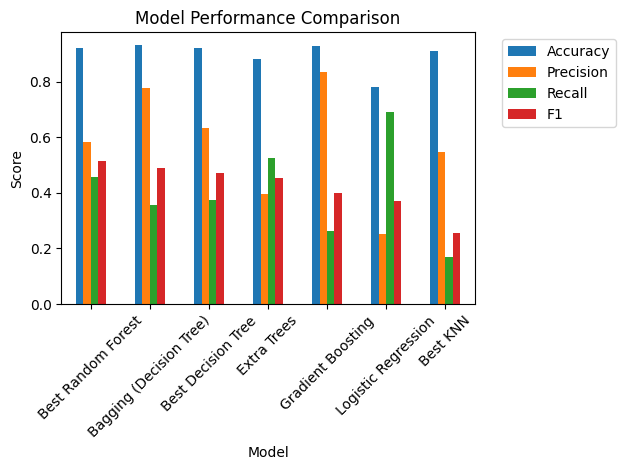

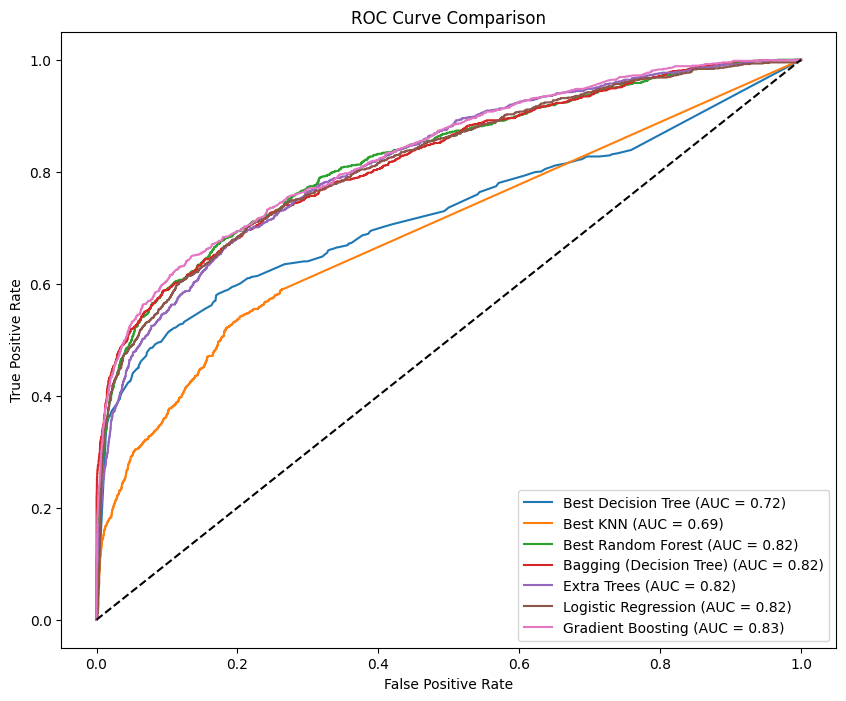

In [26]:
# Results Visualization
"""
Final Delivery Topic: Visual Elements
Comparing model performance visually.
"""
# Metrics comparison
plt.figure(figsize=(12,6))
results_df.set_index('Model').plot(kind='bar', y=['Accuracy', 'Precision', 'Recall', 'F1'])
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(10,8))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_preprocessed)[:,1] if hasattr(model, "predict_proba") else [0]*len(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

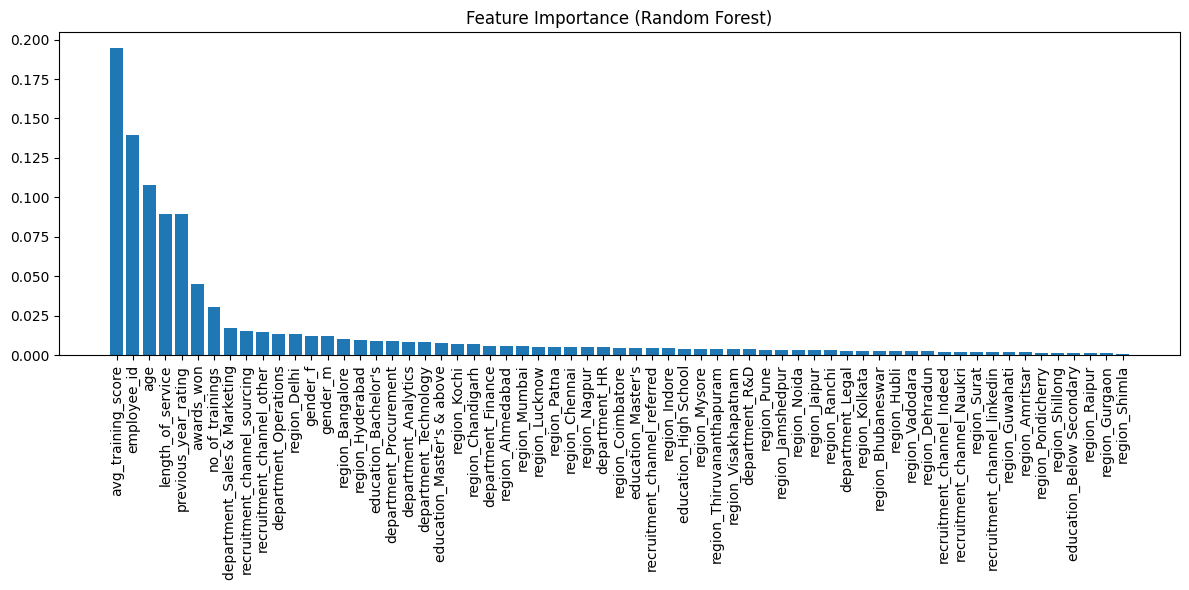

In [ ]:
# Feature Importance
"""
Final Delivery Topic: Visual Elements
Understanding which features drive predictions.
"""
# Get feature importance from Random Forest
rf = models['Random Forest']
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(12,6))
plt.title('Feature Importance (Random Forest)')
# The number of features after preprocessing (used by Random Forest) is 63, 
# but X.columns has only 12 original feature names. 
# To get correct feature names for plotting, extract them from the preprocessor.

# Get feature names from preprocessor
num_features = preprocessor.named_transformers_['num'].named_steps['imputer'].feature_names_in_
cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_features, cat_features])

plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), all_feature_names[indices], rotation=90)
# No need for this line, as all_feature_names already matches the preprocessed feature space
# plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter Tuning for All Models
"""
Final Delivery Topic: Machine Learning Models
Comprehensive parameter optimization for all classifiers.
"""

# 1. Decision Tree Tuning
print("\n=== Decision Tree Tuning ===")
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_preprocessed, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best F1 score:", dt_grid.best_score_)

# Store best model
best_dt = dt_grid.best_estimator_

# 2. KNN Tuning
print("\n=== KNN Tuning ===")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1: manhattan, 2: euclidean
}

knn_grid = GridSearchCV(KNeighborsClassifier(),
                      knn_params, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print("Best parameters:", knn_grid.best_params_)
print("Best F1 score:", knn_grid.best_score_)

best_knn = knn_grid.best_estimator_


# 4. Random Forest Tuning (Enhanced version)
print("\n=== Random Forest Tuning ===")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best F1 score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

# Update models dictionary with tuned models
tuned_models = {
    "Tuned Decision Tree": best_dt,
    "Tuned KNN": best_knn,
    "Tuned SVM": best_svm,
    "Tuned Random Forest": best_rf
}


=== Decision Tree Tuning ===


KeyboardInterrupt: 

In [ ]:
# Evaluate Tuned Models
"""
Final Delivery Topic: Evaluation and Comparison
Comparing performance of tuned models versus baseline.
"""
tuned_results = []

for name, model in tuned_models.items():
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1] if hasattr(model, "predict_proba") else [0]*len(X_test)
    elapsed_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC curve data
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    tuned_results.append([
        name, accuracy, precision, recall, f1, roc_auc, elapsed_time
    ])

# Create comparison dataframe
tuned_results_df = pd.DataFrame(tuned_results,
                              columns=['Model', 'Accuracy', 'Precision',
                                      'Recall', 'F1', 'ROC AUC', 'Prediction Time'])
tuned_results_df.sort_values('F1', ascending=False, inplace=True)

# Display results
print("\n=== Tuned Models Performance ===")
display(tuned_results_df)

# Visual comparison
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='F1', data=tuned_results_df)
plt.title('F1 Scores of Tuned Models')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()